In [10]:
from surya.layout import LayoutPredictor
from surya.foundation import FoundationPredictor
from PIL import Image
from surya.settings import settings

fp = FoundationPredictor(checkpoint=settings.LAYOUT_MODEL_CHECKPOINT)
lp = LayoutPredictor(fp)


In [11]:
jpg_path = 'PMC3576793_00004.jpg'
from pathlib import Path
Path(jpg_path).exists()


True

In [12]:
import torch
print(torch.cuda.is_available())


True


In [13]:
from PIL import Image, ImageDraw, ImageFont


LABEL_COLORS = {
    "Text": "#d62828",
    "SectionHeader": "#1d4ed8",
    "Picture": "#2b9348",
    "Caption": "#f77f00",
    "PageFooter": "#7b2cbf",
    "PageHeader": "#0f766e",
    "ListItem": "#c1121f",
    "Code": "#9c27b0",
}


def annotate_layout(image, layout_result):
    img = image.convert("RGB").copy()

    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("DejaVuSans.ttf", 20)
    except:
        font = ImageFont.load_default()

    for box in layout_result.bboxes:
        x1, y1, x2, y2 = map(int, box.bbox)

        label = str(box.label)
        confidence = float(box.confidence)

        color = LABEL_COLORS.get(label, "#ff0000")

        draw.rectangle(
            [(x1, y1), (x2, y2)],
            outline=color,
            width=4,
        )

        text = f"{label} {confidence:.2f}"

        text_bbox = draw.textbbox((0, 0), text, font=font)

        text_w = text_bbox[2] - text_bbox[0]
        text_h = text_bbox[3] - text_bbox[1]

        text_x = x1
        text_y = max(0, y1 - text_h - 4)

        draw.rectangle(
            [
                (text_x, text_y),
                (text_x + text_w + 8, text_y + text_h + 4),
            ],
            fill=color,
        )

        draw.text(
            (text_x + 4, text_y + 2),
            text,
            fill="white",
            font=font,
        )

    return img


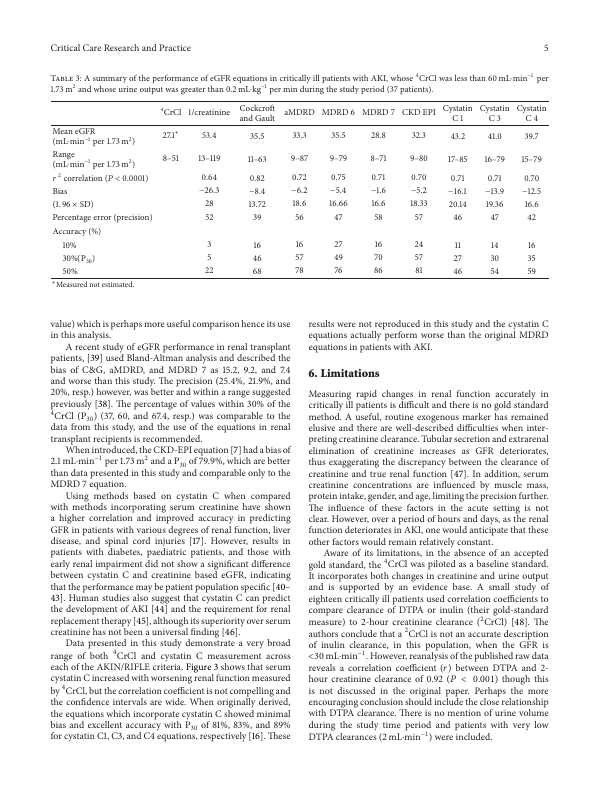

In [14]:
img = Image.open(jpg_path)
img


In [16]:
layout = lp([img])


Recognizing Layout: 100%|██████████| 1/1 [00:00<00:00,  5.26it/s]


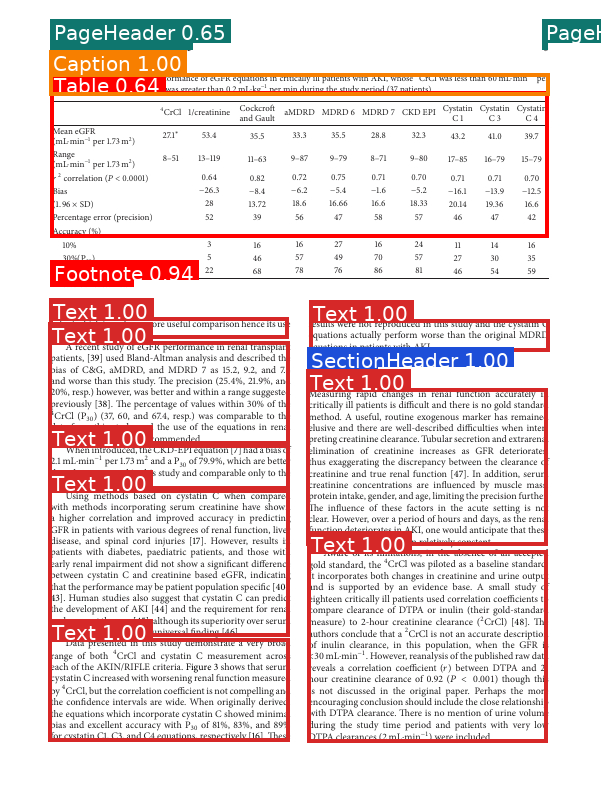

In [17]:
annotated_result = annotate_layout(img, layout[0])

annotated_result


In [18]:
import rich

rich.print(layout)


[
    LayoutResult(
        bboxes=[
            LayoutBox(
                polygon=[
                    [50.474609375, 42.92578125],
                    [192.5078125, 42.92578125],
                    [192.5078125, 49.88671875],
                    [50.474609375, 49.88671875]
                ],
                confidence=0.6519727110862732,
                label='PageHeader',
                position=0,
                top_k={
                    'PageHeader': 0.6519727110862732,
                    'Text': 0.3278324604034424,
                    'Table': 0.01737448386847973,
                    'Caption': 0.002664463361725211,
                    'SectionHeader': 4.9184101953869686e-05
                },
                bbox=[50.474609375, 42.92578125, 192.5078125, 49.88671875]
            ),
            LayoutBox(
                polygon=[
                    [542.01513671875, 42.92578125],
                    [547.29736328125, 42.92578125],
                    [547.29736328125, 49.88671875],
                    [542.01513671875, 49.88671875]
                ],
                confidence=0.9966287016868591,
                label='PageHeader',
                position=1,
                top_k={
                    'PageHeader': 0.9966287016868591,
                    'Caption': 0.0024703957606106997,
                    'Table': 0.0007773445104248822,
                    'Text': 9.284055704483762e-05,
                    'Picture': 1.1262837688263971e-05
                },
                bbox=[542.01513671875, 42.92578125, 547.29736328125, 49.88671875]
            ),
            LayoutBox(
                polygon=[
                    [50.474609375, 91.65234375],
                    [548.177734375, 91.65234375],
                    [548.177734375, 237.83203125],
                    [50.474609375, 237.83203125]
                ],
                confidence=0.636440098285675,
                label='Table',
                position=2,
                top_k={
                    'Table': 0.636440098285675,
                    'Caption': 0.3626326024532318,
                    'Text': 0.000678507552947849,
                    'Figure': 9.623282676329836e-05,
                    'PageHeader': 8.103616710286587e-05
                },
                bbox=[50.474609375, 91.65234375, 548.177734375, 237.83203125]
            ),
            LayoutBox(
                polygon=[
                    [49.30078125, 73.4765625],
                    [549.3515625, 73.4765625],
                    [549.3515625, 95.1328125],
                    [49.30078125, 95.1328125]
                ],
                confidence=0.9995627999305725,
                label='Caption',
                position=3,
                top_k={
                    'Caption': 0.9995627999305725,
                    'Table': 0.00015351883484981954,
                    'Footnote': 0.00010551184823270887,
                    'SectionHeader': 8.21727080619894e-05,
                    'Text': 7.719411951256916e-05
                },
                bbox=[49.30078125, 73.4765625, 549.3515625, 95.1328125]
            ),
            LayoutBox(
                polygon=[
                    [50.76806640625, 279.59765625],
                    [133.52294921875, 279.59765625],
                    [133.52294921875, 286.55859375],
                    [50.76806640625, 286.55859375]
                ],
                confidence=0.938569962978363,
                label='Footnote',
                position=4,
                top_k={
                    'Footnote': 0.938569962978363,
                    'Text': 0.060000769793987274,
                    'SectionHeader': 0.0005701290210708976,
                    'Caption': 0.0003797877870965749,
                    'Table': 0.00020328574464656413
                },
                bbox=[50.76806640625, 279.59765625, 133.52294921875, 286.55859375]
            ),
            LayoutBox(
                polygon=[
                    [49.30078125